<a href="https://colab.research.google.com/github/lilianabs/ml-algorithms-from-scratch/blob/main/nns_from_scratch_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import matplotlib.pyplot as plt


In [27]:
# Data Generation
np.random.seed(42)
x = np.random.rand(100, 1)
y = 1 + 2 * x + .1 * np.random.randn(100, 1)

# Shuffles the indices
idx = np.arange(100)
np.random.shuffle(idx)

# Uses first 80 random indices for train
train_idx = idx[:80]
# Uses the remaining indices for validation
val_idx = idx[80:]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

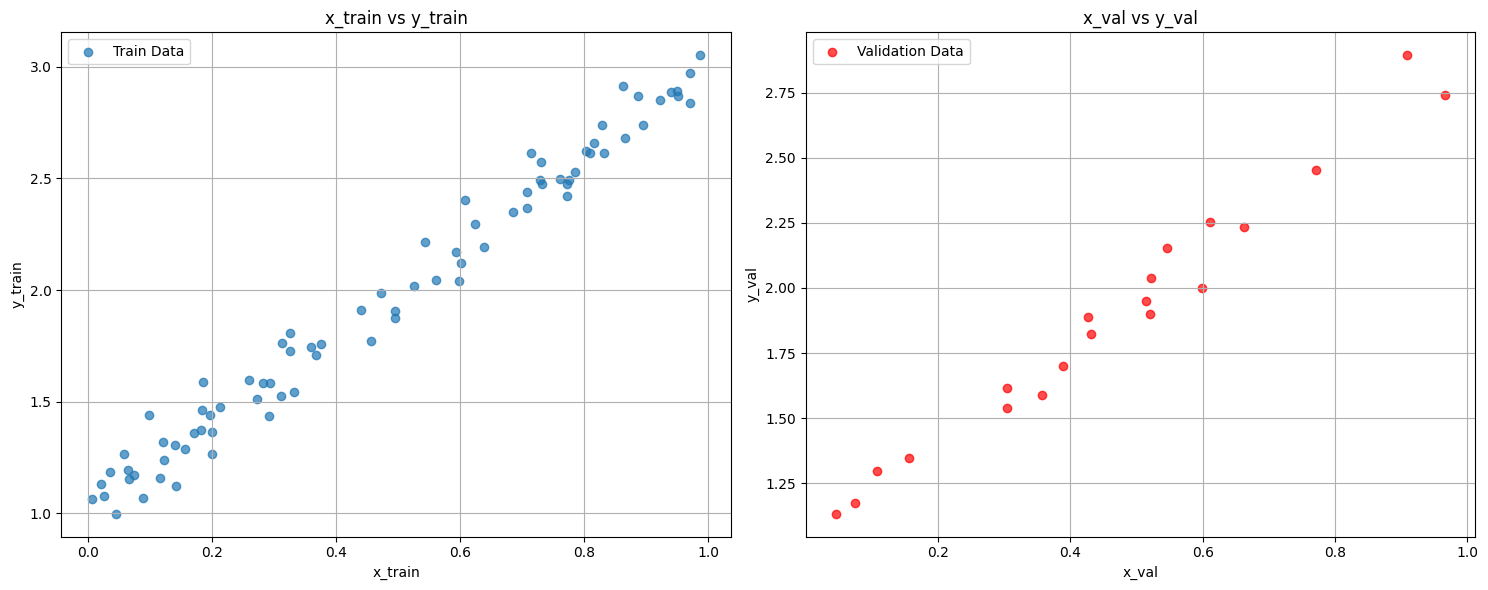

In [28]:
plt.figure(figsize=(15, 6))

# Subplot 1: x_train vs y_train
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(x_train, y_train, alpha=0.7, label='Train Data')
plt.title('x_train vs y_train')
plt.xlabel('x_train')
plt.ylabel('y_train')
plt.legend()
plt.grid(True)

# Subplot 2: x_val vs y_val
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(x_val, y_val, alpha=0.7, label='Validation Data', color='red')
plt.title('x_val vs y_val')
plt.xlabel('x_val')
plt.ylabel('y_val')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Linear regression in Numpy

In [29]:
a = np.random.rand()
b = np.random.rand()

print(f"a: {a}")
print(f"b: {b}")

a: 0.5163003483011953
b: 0.32295647294124596


In [38]:
# Initialization of hyper parameters
learning_rate = 1e-1
num_epochs = 1000

In [31]:
# Forward pass
y_pred = a + (b * x_train)

In [32]:
def mse(y, y_pred):
  n = len(y)
  loss = sum( (y - y_pred) ** 2) / n
  return loss

In [33]:
print(mse(y_train, y_pred))

[1.9131076]


In [34]:
# Compute the gradients
n = len(x_train)
da = (-2 / n) * sum(y_train - y_pred)
db = (-2 / n) * sum( (y_train - y_pred) * x_train)

In [35]:
# Update the parameters
temp_a = da * learning_rate
a = a - (temp_a)

temp_b = db * learning_rate
b = b - (temp_b)

In [37]:
a

array([0.54199858])

## Training loop

In [44]:
a = np.random.randn(1)
b = np.random.randn(1)

print(f"a: {a}")
print(f"b: {b}")

lr = 1e-1
n_epochs = 100

train_loss = []
val_loss = []

for epoch in range(n_epochs):
  # Forward pass
  y_pred = a + b * x_train

  # Compute train loss
  error = (y_train - y_pred)
  loss = (error ** 2).mean()
  train_loss.append(loss)

  # Compute gradients
  grad_a = -2 * error.mean()
  grad_b = -2 * (x_train * error).mean()

  # Update parameters
  a = a - lr * grad_a
  b = b - lr * grad_b

a: [0.50498728]
b: [0.86575519]


## Train and val loss

In [47]:
a = np.random.randn(1)
b = np.random.randn(1)

print(f"a: {a}")
print(f"b: {b}")

def compute_loss(y_true, y_pred):
  error = (y_true - y_pred)
  loss = (error ** 2).mean()
  return loss

def pred(x, a, b):
  return a + b * x

lr = 1e-1
n_epochs = 100

train_loss = []
val_loss = []

for epoch in range(n_epochs):
  # Forward pass
  y_train_pred = pred(x_train, a, b)
  y_val_pred = pred(x_val, a, b)

  # Compute train loss
  current_train_loss = compute_loss(y_train, y_train_pred)
  train_loss.append(current_train_loss)

  # Compute validation loss
  current_val_loss = compute_loss(y_val, y_val_pred)
  val_loss.append(current_val_loss)

  # Compute gradients (using training data)
  error_train = (y_train - y_train_pred)
  grad_a = -2 * error_train.mean()
  grad_b = -2 * (x_train * error_train).mean()

  # Update parameters
  a = a - lr * grad_a
  b = b - lr * grad_b

a: [-0.47494531]
b: [-0.65332923]


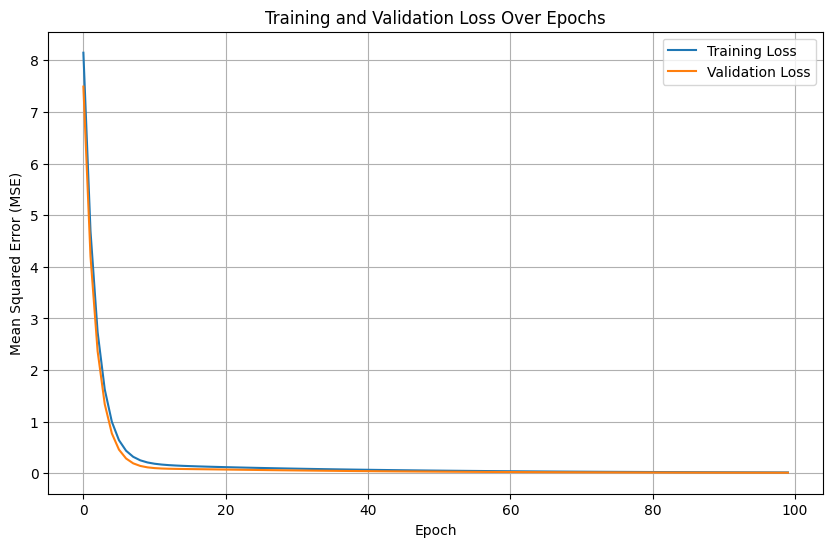

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_loss)), train_loss, label='Training Loss')
plt.plot(range(len(val_loss)), val_loss, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.show()